In [127]:
import pandas as pd
import re
import spacy

nlp = spacy.load("en_core_web_sm")

def first_n_words(text, n=35):
    words = text.split()
    return ' '.join(words[:n])

def cut_to_n_sentences(text):
    doc = nlp(text)
    return ' '.join([sent.text for sent in (list(doc.sents)[:2] + list(doc.sents)[-2:])])

_CLEAN_RE = re.compile(r"[^A-Za-z\s]+")   # non-letters 

def parse_text(df):
    return df.str.replace(_CLEAN_RE, "", regex=True)

fake = pd.read_csv("data/Fake.csv")
real = pd.read_csv("data/True.csv")

fake["label"] = 0   # Fake
real["label"] = 1   # Real

df_concat = pd.concat([fake, real], ignore_index=True)
df_concat["text"] = df_concat["text"].map(first_n_words)
df_concat["text"] = df_concat["title"] + " " + df_concat["text"]
df_concat = df_concat[["text", "label"]]

df = df_concat.sample(frac=1, random_state=42).reset_index(drop=True)

test = df["text"].iloc[:1000].map(first_n_words)
testlen = test.map(len)
testend = test.map(lambda x : x[-45:])
print(test)
print(testlen)
print(testend)

0      Ben Stein Calls Out 9th Circuit Court: Committ...
1      Trump drops Steve Bannon from National Securit...
2      Puerto Rico expects U.S. to lift Jones Act shi...
3      OOPS: Trump Just Accidentally Confirmed He Lea...
4      Donald Trump heads for Scotland to reopen a go...
                             ...                        
995    Path cleared for Congress to consider U.S. arm...
996    Democrats urge full review before Senate vote ...
997    WHY PICTURE OF CHE-OBAMA Was Much Worse Than A...
998    #Berkeley CRAZY! RIOTERS CHASE And Beat People...
999    Democratic senators urge speed on Supreme Cour...
Name: text, Length: 1000, dtype: object
0      226
1      250
2      224
3      246
4      227
      ... 
995    231
996    221
997    234
998    217
999    237
Name: text, Length: 1000, dtype: int64
0      some Hollywood fame appearing in TV shows and
1      ng his controversial decision early this year
2      e Jones Act, which would lift restrictions on
3      he extr

In [128]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

In [129]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_NAME = "Pulk17/Fake-News-Detection"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [130]:
import numpy as np

def _to_list_of_str(texts):
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()
    if isinstance(texts, str):
        return [texts]

    return ["" if t is None else str(t) for t in texts]

def tokenize(texts):
    texts = _to_list_of_str(texts)
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

def predict(texts):
    texts = _to_list_of_str(texts)
    with torch.no_grad():
        inputs = tokenize(texts)
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return probs.cpu().numpy()

def predict_tokens(tokens):
    with torch.no_grad():
        outputs = model(**tokens)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)

    return probs

In [131]:
import torch
import numpy as np
from tqdm import tqdm

def batch_encodings(test_encodings, first, last):
    batch_input_ids = test_encodings['input_ids'][first:last]
    batch_attention_mask = test_encodings['attention_mask'][first:last]
    batch_token_type_ids = test_encodings['token_type_ids'][first:last]

    return {
        'input_ids': batch_input_ids,
        'attention_mask': batch_attention_mask,
        'token_type_ids': batch_token_type_ids
    }

TEST_N_BATCHES = 8

test_encodings = tokenize(test_texts)
test_encodings = {k: v.to(device) for k, v in test_encodings.items()}

batch_size = 16 
test_labels = test_labels[:TEST_N_BATCHES * batch_size]

# Define a batch size for inference to prevent OutOfMemory errors
predictions = []

# Get the total number of test samples
num_samples = test_encodings['input_ids'].shape[0]

with torch.no_grad():
    # for i in tqdm(range(0, num_samples, batch_size)):
    for i in tqdm(range(0, batch_size * TEST_N_BATCHES, batch_size)):
        # Extract batch from test_encodings
        batch = batch_encodings(test_encodings, i, i + batch_size)

        # Perform inference on the batch
        outputs = model(**batch)
        batch_predictions = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        predictions.extend(batch_predictions)

# Convert the list of predictions to a numpy array
predictions = np.array(predictions)

100%|██████████| 8/8 [00:26<00:00,  3.28s/it]


In [132]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(test_labels, predictions)
print(f"Test Accuracy: {accuracy:.4f}\n")
print(classification_report(test_labels, predictions, target_names=["Fake", "Real"]))

Test Accuracy: 0.9141

              precision    recall  f1-score   support

        Fake       0.85      1.00      0.92        62
        Real       1.00      0.83      0.91        66

    accuracy                           0.91       128
   macro avg       0.92      0.92      0.91       128
weighted avg       0.93      0.91      0.91       128



In [133]:
import shap

BG_N = 20

background_texts = pd.concat([
    fake.sample(BG_N, random_state=42),
    real.sample(BG_N, random_state=42)
])['text'].dropna().tolist()

In [134]:
eval_texts = df['text'].dropna().tolist()[:2]
print(eval_texts)

masker = shap.maskers.Text(
    tokenizer=None,  
#   mask_token=tokenizer.mask_token,
)

explainer = shap.Explainer(
    predict,
    masker,
    output_names=['fake', 'real'],
    algorithm='partition',
    data=background_texts,
)

shap_values = explainer(eval_texts)

['Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge', 'Trump drops Steve Bannon from National Security Council WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year to give a political adviser an unprecedented role']


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [00:33, 16.72s/it]               


In [135]:
def top_words(shap_values, n=1, sample_idx=0, class_idx=0, top_k=10):
    dfs = []

    for sample_idx in range(n):
        values = shap_values.values[sample_idx][:, class_idx]
        tokens = shap_values.data[sample_idx]

        df = pd.DataFrame({
            "token": tokens,
            "importance": values
        })

        df = df[df.token.str.strip() != ""]
        df["abs"] = df.importance.abs()

        dfs.append(df.sort_values("abs", ascending=False).head(top_k))

    return dfs

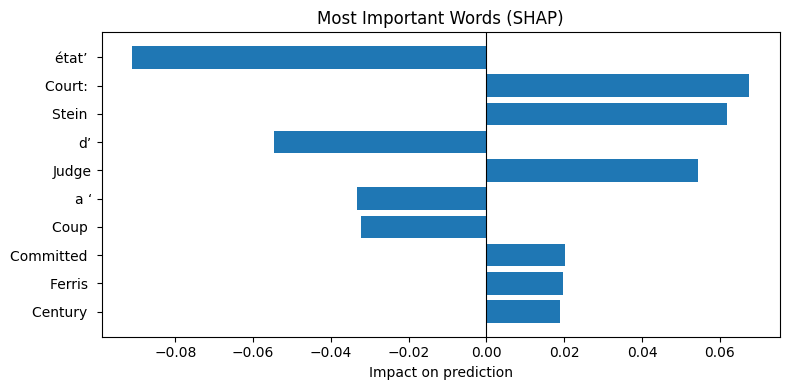

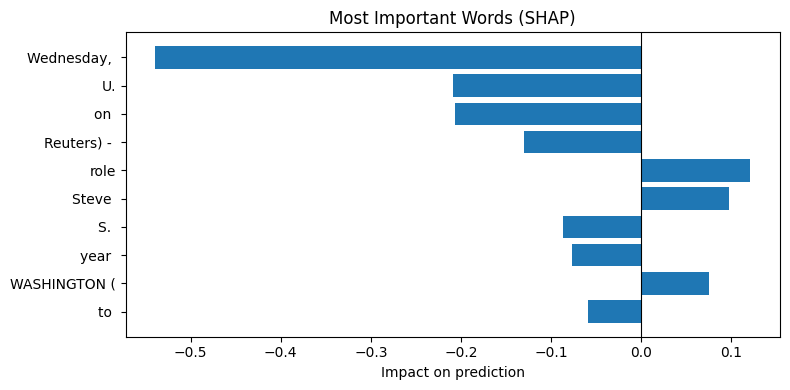

In [136]:
import matplotlib.pyplot as plt

def plot_top_words(dfs):
    for i in range(len(dfs)):
        plt.figure(figsize=(8, 4))
        plt.barh(
            dfs[i].token[::-1],
            dfs[i].importance[::-1]
        )
        plt.axvline(0, color="black", linewidth=0.8)
        plt.title("Most Important Words (SHAP)")
        plt.xlabel("Impact on prediction")
        plt.tight_layout()
        plt.show()

plot_top_words(top_words(shap_values, 2))

In [148]:
N_TEXTS = 100
texts = df_concat['text'].dropna().tolist()[:N_TEXTS]
first_prediction = predict(texts)
print(first_prediction)

for _ in tqdm(range(10)):
    shap_values = explainer(texts)

    for i in range(N_TEXTS):
        values = shap_values.values[i][:, 0]
        words = shap_values.data[i]

        most_influential = np.argmax(values)

        new_words = np.concat([words[:most_influential], words[most_influential + 1:]])
        new_text = ''.join(new_words)

        texts[i] = new_text

second_prediction = predict(texts)
print(second_prediction)

print(first_prediction.T[0] - second_prediction.T[0])

[[9.9974233e-01 2.5768290e-04]
 [9.9960047e-01 3.9952909e-04]
 [9.2603087e-01 7.3969141e-02]
 [9.9876058e-01 1.2394714e-03]
 [9.9970168e-01 2.9827136e-04]
 [9.9967432e-01 3.2563633e-04]
 [9.9971062e-01 2.8940829e-04]
 [9.9885464e-01 1.1454005e-03]
 [9.9971908e-01 2.8095330e-04]
 [9.9971956e-01 2.8037239e-04]
 [9.9860483e-01 1.3951428e-03]
 [9.9960524e-01 3.9473458e-04]
 [9.9932754e-01 6.7246531e-04]
 [9.9958068e-01 4.1930398e-04]
 [9.9939954e-01 6.0050725e-04]
 [9.9944347e-01 5.5646372e-04]
 [9.9898571e-01 1.0142941e-03]
 [9.9968362e-01 3.1637447e-04]
 [9.9959594e-01 4.0402406e-04]
 [9.9945778e-01 5.4227258e-04]
 [9.9747485e-01 2.5250965e-03]
 [9.9962258e-01 3.7737086e-04]
 [9.9958354e-01 4.1649549e-04]
 [9.9975926e-01 2.4071308e-04]
 [9.9875021e-01 1.2498071e-03]
 [9.9972528e-01 2.7470361e-04]
 [9.9941969e-01 5.8032037e-04]
 [9.9864370e-01 1.3562615e-03]
 [9.9913436e-01 8.6569641e-04]
 [9.7631913e-01 2.3680883e-02]
 [9.9925345e-01 7.4651715e-04]
 [9.9971658e-01 2.8340603e-04]
 [9.8349

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 101it [18:05, 10.96s/it]
100%|██████████| 10/10 [3:05:56<00:00, 1115.64s/it]


[[9.9966788e-01 3.3217587e-04]
 [9.9968088e-01 3.1912571e-04]
 [2.0390470e-03 9.9796093e-01]
 [9.7910345e-01 2.0896515e-02]
 [9.9927109e-01 7.2887231e-04]
 [9.9912912e-01 8.7091658e-04]
 [9.9973959e-01 2.6044456e-04]
 [9.9811977e-01 1.8802467e-03]
 [9.9958414e-01 4.1591009e-04]
 [9.9970704e-01 2.9292397e-04]
 [9.9976224e-01 2.3777534e-04]
 [9.9970895e-01 2.9106130e-04]
 [9.9659866e-01 3.4013432e-03]
 [9.9919242e-01 8.0763182e-04]
 [9.9957472e-01 4.2526488e-04]
 [9.9934953e-01 6.5046118e-04]
 [8.7815970e-01 1.2184034e-01]
 [9.9968386e-01 3.1611486e-04]
 [9.9956995e-01 4.3005255e-04]
 [9.9976188e-01 2.3810157e-04]
 [9.9772972e-01 2.2702699e-03]
 [9.9959272e-01 4.0726434e-04]
 [9.9921012e-01 7.8984600e-04]
 [9.9982446e-01 1.7560956e-04]
 [9.9939525e-01 6.0473010e-04]
 [9.9961025e-01 3.8973967e-04]
 [9.9926502e-01 7.3503156e-04]
 [9.9158865e-01 8.4113153e-03]
 [6.7727687e-04 9.9932277e-01]
 [6.7772990e-01 3.2227010e-01]
 [9.9952102e-01 4.7899008e-04]
 [9.9962068e-01 3.7930970e-04]
 [9.1897

In [ ]:
predict(texts)

array([[1.4029272e-01, 8.5970736e-01],
       [9.9940765e-01, 5.9240474e-04]], dtype=float32)